# 241: What every alphabet can see, on three test cases

Three query proteins, each searched against the same background, the 19_732 canonical
human proteins of GENCODE v49, with all 19 alphabets kmerseek supports:

| case | query | what the right answer is | why it is here |
|---|---|---|---|
| gold standard | Ced9 (*C. elegans*, 280 aa) | BCL2, a known homolog: same SCOP superfamily, structure-verified, under 30% identity | we know the answer, so every metric can be scored on it |
| the reach | P66 (*Borreliella burgdorferi*, 597 aa) | CD47, the proposed partner | a claim that has not been shown; the same scoring says whether any alphabet supports it |
| the application | BHF (*Botryllus schlosseri*, 252 aa) | unknown | the protein the method is for |

Each search writes, for every matched region, the metrics this notebook compares: the
**E-value** (regions this good expected by chance in the whole search, from the
Karlin-Altschul fit on the index), **mean IDF** (how rare the region's k-mers are in the
database), **tf-idf** (the sum of those rarities), **enrichment** (shared k-mers over the
number expected by chance) and the **Poisson p-value** of the shared k-mer count. For the
gold standard and the reach the question is the same under every metric: where does the
known partner rank among all the human proteins that were hit at all?

**Design.** For each alphabet the k ladder is set so one seed carries 16 to 44 bits,
where bits per position is the entropy of the alphabet's class shares measured on this
proteome (`bits_per_position.json`), not log2 of the class count; gbmr7 has 7 classes but
2.0 bits per position because one class holds most residues. Every index is built with
region extension at the alphabet's own optimal mismatch penalty from its measured copy
rate kappa (dark-set `assets/kappa_by_alphabet.tsv`, notebook 230; funcgroups8 has no
kappa and uses 2) and a Karlin-Altschul fit on 200 database sequences, retried with 1_000
sequences and 8 shuffles when refused. When the retry is also refused the search runs
with exact regions, so every metric but the E-value is still computed. Searches keep
every region (`--threshold 0 --min-shared-kmers 1 --max-query-pvalue 1 --min-region-score 0`),
so a rank is over everything, not over a filtered list. The pairwise layer runs
`kmerseek pair` on Ced9/BCL2 and P66/CD47 with no database at all.

Driver: `241_alphabet_ranking_driver.py`. Collector: `241_alphabet_ranking_collect.py`.
Figures: `alphabet_ranking_utils.py`. Data: `/Users/olga/data/botryllus/alphabet-ranking-three-cases/`.

In [1]:
import sys
from pathlib import Path

import polars as pl

sys.path.insert(0, str(Path.cwd()))
import alphabet_ranking_utils as au

pl.Config.set_tbl_rows(200)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(40)

arms, ranks = au.load()
FIG = au.FIG
bits = pl.DataFrame({"alphabet": list(au.CLASSES), "classes": list(au.CLASSES.values())}).join(
    pl.DataFrame(arms.group_by("alphabet").agg((pl.col("bits") / pl.col("ksize")).first().alias("bits_per_position"))),
    on="alphabet").sort("classes", "alphabet")
print(f"{arms.height} arms over {arms['alphabet'].n_unique()} alphabets; "
      f"{arms.filter(pl.col('searched')).height} searched")
print(bits.with_columns(pl.col("bits_per_position").round(3)))

152 arms over 19 alphabets; 152 searched
shape: (19, 3)
┌──────────────────────────┬─────────┬───────────────────┐
│ alphabet                 ┆ classes ┆ bits_per_position │
│ ---                      ┆ ---     ┆ ---               │
│ str                      ┆ i64     ┆ f64               │
╞══════════════════════════╪═════════╪═══════════════════╡
│ hp_kyte_doolittle2       ┆ 2       ┆ 0.937             │
│ hp_lehninger2            ┆ 2       ┆ 1.0               │
│ hp_lehninger_c_nonpolar2 ┆ 2       ┆ 0.999             │
│ hp_pbotc_1st_ed2         ┆ 2       ┆ 0.994             │
│ hp_thomas_dill2          ┆ 2       ┆ 0.966             │
│ hp_thomas_dill_no_c2     ┆ 2       ┆ 0.95              │
│ hp_lehninger_hpc3        ┆ 3       ┆ 1.134             │
│ gbmr4                    ┆ 4       ┆ 1.528             │
│ polarity4                ┆ 4       ┆ 1.784             │
│ wwmj5                    ┆ 5       ┆ 2.197             │
│ dayhoff6                 ┆ 6       ┆ 2.281             │


## 1. Which arms got an E-value

The Karlin-Altschul fit needs four score bins with 30 regions in both the real and the
shuffled curve. Above about 30 bits per seed both curves run short and the fit is
refused; the retry with more queries and shuffles rescues some. An arm without a fit has
every metric but the E-value.

In [2]:
fit = (arms.with_columns(
        pl.when(pl.col("fitted") == True).then(pl.lit("fitted"))
          .when(pl.col("fitted") == False).then(pl.lit("refused: no E-value"))
          .otherwise(pl.lit("not run")).alias("fit"))
    .group_by("alphabet", "fit").agg(pl.len().alias("arms"), pl.col("bits").min().round(0).alias("from_bits"),
                                     pl.col("bits").max().round(0).alias("to_bits"))
    .sort("alphabet", "fit"))
print(fit)
n_fit = arms.filter(pl.col("fitted") == True).height
n_ref = arms.filter(pl.col("fitted") == False).height
print(f"\n{n_fit} arms fitted, {n_ref} refused after the retry (no E-value), "
      f"{arms.filter(pl.col('fitted').is_null()).height} not run")

shape: (38, 5)
┌──────────────────────────┬─────────────────────┬──────┬───────────┬─────────┐
│ alphabet                 ┆ fit                 ┆ arms ┆ from_bits ┆ to_bits │
│ ---                      ┆ ---                 ┆ ---  ┆ ---       ┆ ---     │
│ str                      ┆ str                 ┆ u32  ┆ f64       ┆ f64     │
╞══════════════════════════╪═════════════════════╪══════╪═══════════╪═════════╡
│ dayhoff6                 ┆ fitted              ┆ 4    ┆ 16.0      ┆ 27.0    │
│ dayhoff6                 ┆ refused: no E-value ┆ 5    ┆ 32.0      ┆ 43.0    │
│ funcgroups8              ┆ fitted              ┆ 1    ┆ 33.0      ┆ 33.0    │
│ funcgroups8              ┆ refused: no E-value ┆ 7    ┆ 16.0      ┆ 44.0    │
│ gbmr4                    ┆ fitted              ┆ 5    ┆ 15.0      ┆ 32.0    │
│ gbmr4                    ┆ refused: no E-value ┆ 3    ┆ 37.0      ┆ 44.0    │
│ gbmr7                    ┆ fitted              ┆ 1    ┆ 16.0      ┆ 16.0    │
│ gbmr7                  

## 2. The pairwise layer: do the two proteins share any exact k-mer at all?

No database. `kmerseek pair` lists every exact k-mer the two proteins share and the
regions they chain into. A shared k-mer is necessary for a search hit, so this panel is
the ceiling: an alphabet with a grey cross here can never rank the partner anywhere.
For Ced9/BCL2 the black ring marks a shared region inside the BH3-binding groove, the
one place the two proteins are known to align (Ced9 162-181 against BCL2 138-157 in the
first hp_lehninger2 k=17 run; the window is drawn wide at 150-195 / 125-170).

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (33, 6)
┌──────────────────────────┬───────┬───────┬────────────────────────┬─────────────────────┬───────────────────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ pair_Ced9_shared_kmers ┆ pair_Ced9_in_window ┆ pair_P66_shared_kmers │
│ ---                      ┆ ---   ┆ ---   ┆ ---                    ┆ ---                 ┆ ---                   │
│ str                      ┆ i64   ┆ f64   ┆ i64                    ┆ bool                ┆ i64                   │
╞══════════════════════════╪═══════╪═══════╪════════════════════════╪═════════════════════╪═══════════════════════╡
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ 1                      ┆ false               ┆ 6                     │
│ funcgroups8              ┆ 6     ┆ 16.37 ┆ 11                     ┆ false               ┆ 58                    │
│ funcgroups8              ┆ 7     ┆ 19.1  ┆ 5                      ┆ false               ┆ 16                    │
│ funcgroups8              ┆ 9     ┆ 24.55 ┆ 1           

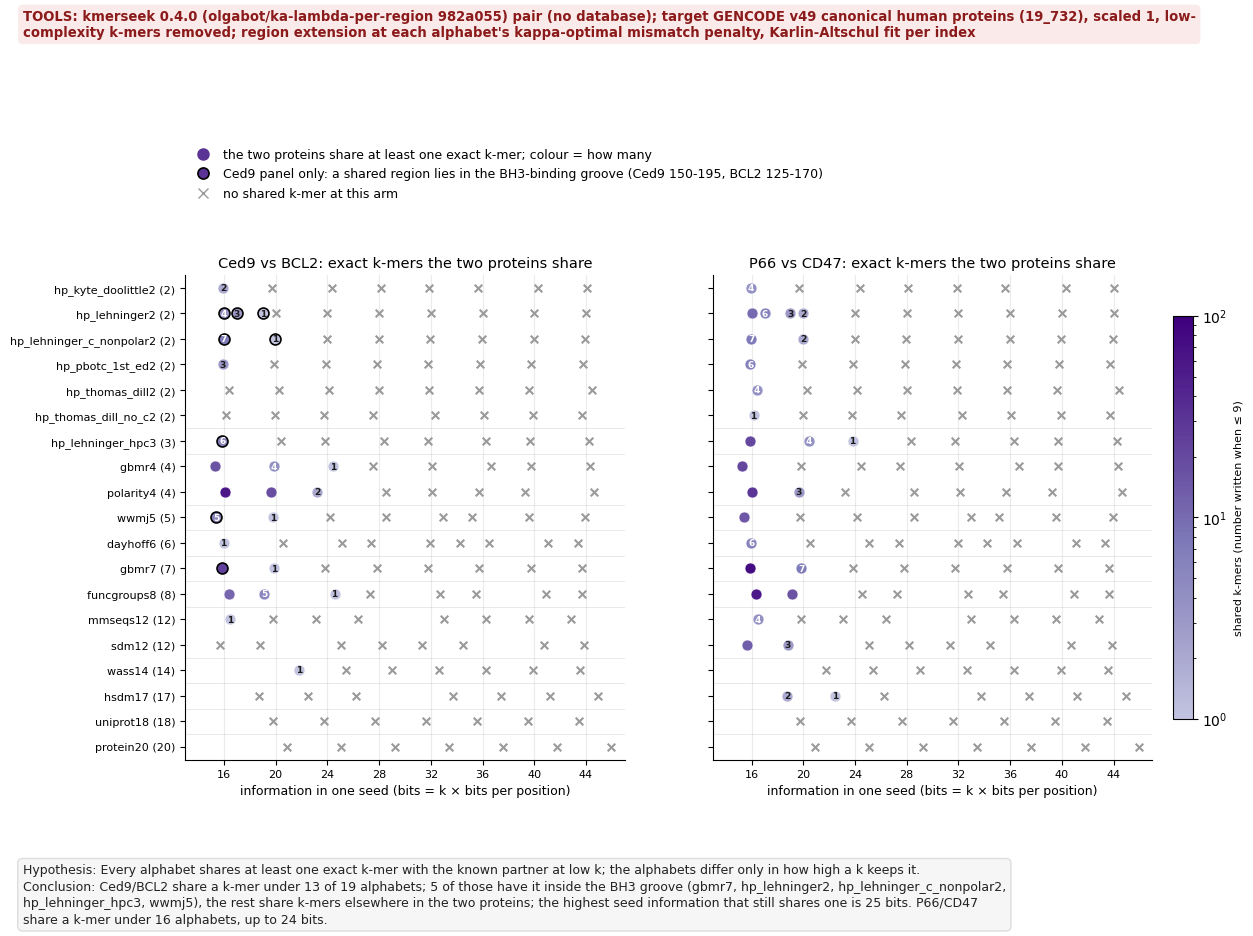

In [3]:
pair_tbl = au.pair_matrix(
    arms, FIG / "241_pairwise_shared_kmers.png",
    hypothesis="Every alphabet shares at least one exact k-mer with the known partner at low k; the alphabets differ only in how high a k keeps it.",
    conclusion=(lambda t: (
        f"Ced9/BCL2 share a k-mer under {t.filter(pl.col('pair_Ced9_shared_kmers') > 0)['alphabet'].n_unique()} of 19 alphabets; "
        f"{t.filter(pl.col('pair_Ced9_in_window') == True)['alphabet'].n_unique()} of those have it inside the BH3 groove "
        f"({', '.join(sorted(t.filter(pl.col('pair_Ced9_in_window') == True)['alphabet'].unique()))}), the rest share k-mers elsewhere in the two proteins; "
        f"the highest seed information that still shares one is {t.filter(pl.col('pair_Ced9_shared_kmers') > 0)['bits'].max():.0f} bits. "
        f"P66/CD47 share a k-mer under {t.filter(pl.col('pair_P66_shared_kmers') > 0)['alphabet'].n_unique()} alphabets, "
        f"up to {t.filter(pl.col('pair_P66_shared_kmers') > 0)['bits'].max():.0f} bits."))(arms),
)
print(pair_tbl.filter((pl.col("pair_Ced9_shared_kmers") > 0) | (pl.col("pair_P66_shared_kmers") > 0)))

## 3. The gold standard: where BCL2 ranks when Ced9 is the query

One dot per arm. Colour is BCL2's rank among every human protein with at least one
region, under that panel's metric; a target's score is its best region. A grey cross
means BCL2 has no region at that arm. An open circle in the E-value panel means the arm
has no E-value. The number of proteins hit falls with seed information (thousands at 16
bits, a handful at 28), so a rank is only comparable to other ranks at the same arm; the
table under the figure carries the denominator.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (102, 10)
┌──────────────────────────┬───────┬───────┬─────────────────┬───────┬────────┬───────────┬───────────────┬──────────────┬─────────────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ metric          ┆ rank  ┆ n_tied ┆ n_targets ┆ partner_value ┆ best_value   ┆ top_gene        │
│ ---                      ┆ ---   ┆ ---   ┆ ---             ┆ ---   ┆ ---    ┆ ---       ┆ ---           ┆ ---          ┆ ---             │
│ str                      ┆ i64   ┆ f64   ┆ str             ┆ i64   ┆ i64    ┆ i64       ┆ f64           ┆ f64          ┆ str             │
╞══════════════════════════╪═══════╪═══════╪═════════════════╪═══════╪════════╪═══════════╪═══════════════╪══════════════╪═════════════════╡
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ Poisson p-value ┆ 16061 ┆ 1      ┆ 16979     ┆ 0.38878       ┆ 5.5511e-16   ┆ TCERG1L         │
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ enrichment      ┆ 15908 ┆ 1      ┆ 16979     ┆ 2.031286      ┆ 4869.5       ┆ NBEAL2        

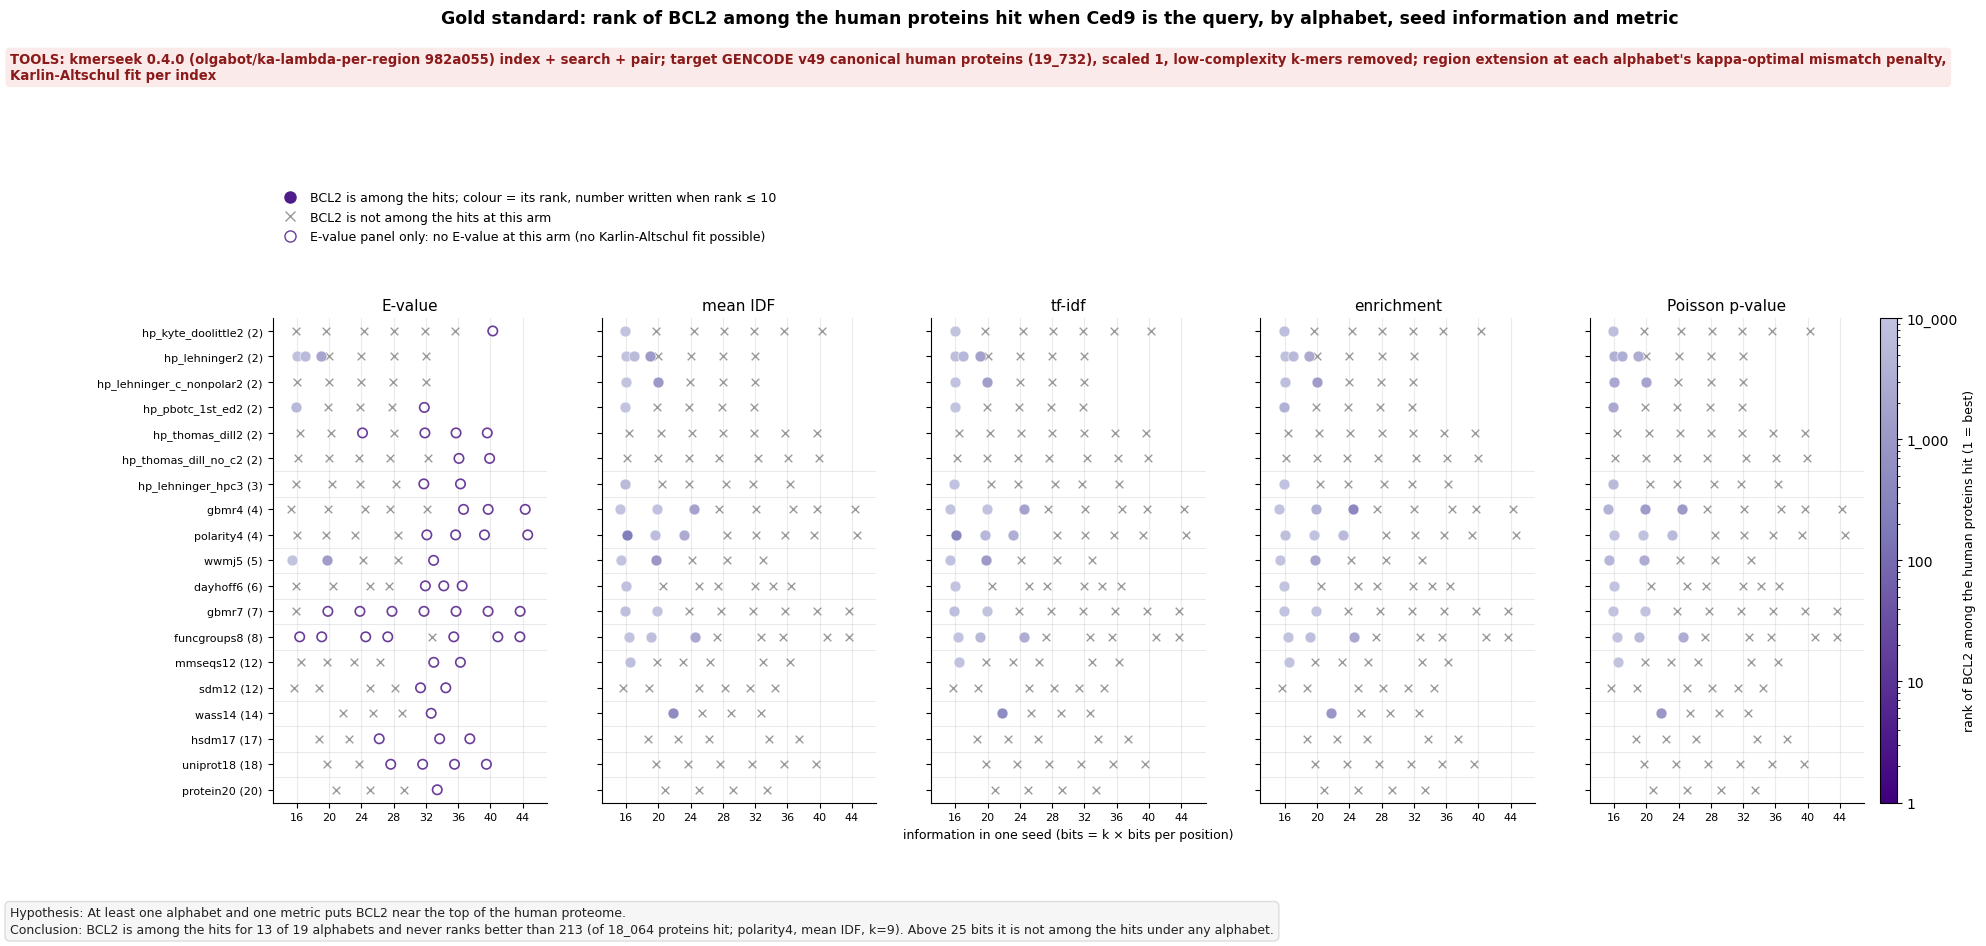

In [4]:
gold = au.rank_matrix(
    ranks, arms, "Ced9", "BCL2", FIG / "241_gold_standard_bcl2_rank.png",
    "Gold standard: rank of BCL2 among the human proteins hit when Ced9 is the query, by alphabet, seed information and metric",
    hypothesis="At least one alphabet and one metric puts BCL2 near the top of the human proteome.",
    conclusion=(lambda b: (
        f"BCL2 is among the hits for {b.filter(pl.col('rank').is_not_null())['alphabet'].n_unique()} of 19 alphabets and never ranks better than "
        f"{b['rank'].min()} (of {b.filter(pl.col('rank') == b['rank'].min())['n_targets'][0]:_} proteins hit; "
        f"{b.filter(pl.col('rank') == b['rank'].min())['alphabet'][0]}, "
        f"{b.filter(pl.col('rank') == b['rank'].min())['metric'][0]}, k={b.filter(pl.col('rank') == b['rank'].min())['ksize'][0]}). "
        f"Above {b.filter(pl.col('rank').is_not_null())['bits'].max():.0f} bits it is not among the hits under any alphabet."))(au.best_per_alphabet(ranks, "Ced9")),
)
print(gold.filter(pl.col("partner_found")).select("alphabet", "ksize", "bits", "metric", "rank", "n_tied", "n_targets", "partner_value", "best_value", "top_gene").sort("alphabet", "ksize", "metric"))

## 4. The reach: where CD47 ranks when P66 is the query

Same layout. CD47 is the proposed partner; nothing here assumes it is right.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (121, 10)
┌──────────────────────────┬───────┬───────┬─────────────────┬───────┬────────┬───────────┬───────────────┬─────────────┬──────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ metric          ┆ rank  ┆ n_tied ┆ n_targets ┆ partner_value ┆ best_value  ┆ top_gene │
│ ---                      ┆ ---   ┆ ---   ┆ ---             ┆ ---   ┆ ---    ┆ ---       ┆ ---           ┆ ---         ┆ ---      │
│ str                      ┆ i64   ┆ f64   ┆ str             ┆ i64   ┆ i64    ┆ i64       ┆ f64           ┆ f64         ┆ str      │
╞══════════════════════════╪═══════╪═══════╪═════════════════╪═══════╪════════╪═══════════╪═══════════════╪═════════════╪══════════╡
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ E-value         ┆ 12601 ┆ 21     ┆ 18946     ┆ 37881.842073  ┆ 8.660913    ┆ ARL1     │
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ Poisson p-value ┆ 11716 ┆ 14     ┆ 18946     ┆ 0.013513      ┆ 5.3291e-14  ┆ FSTL4    │
│ dayhoff6                 ┆ 7     ┆ 15.97 ┆ enrichm

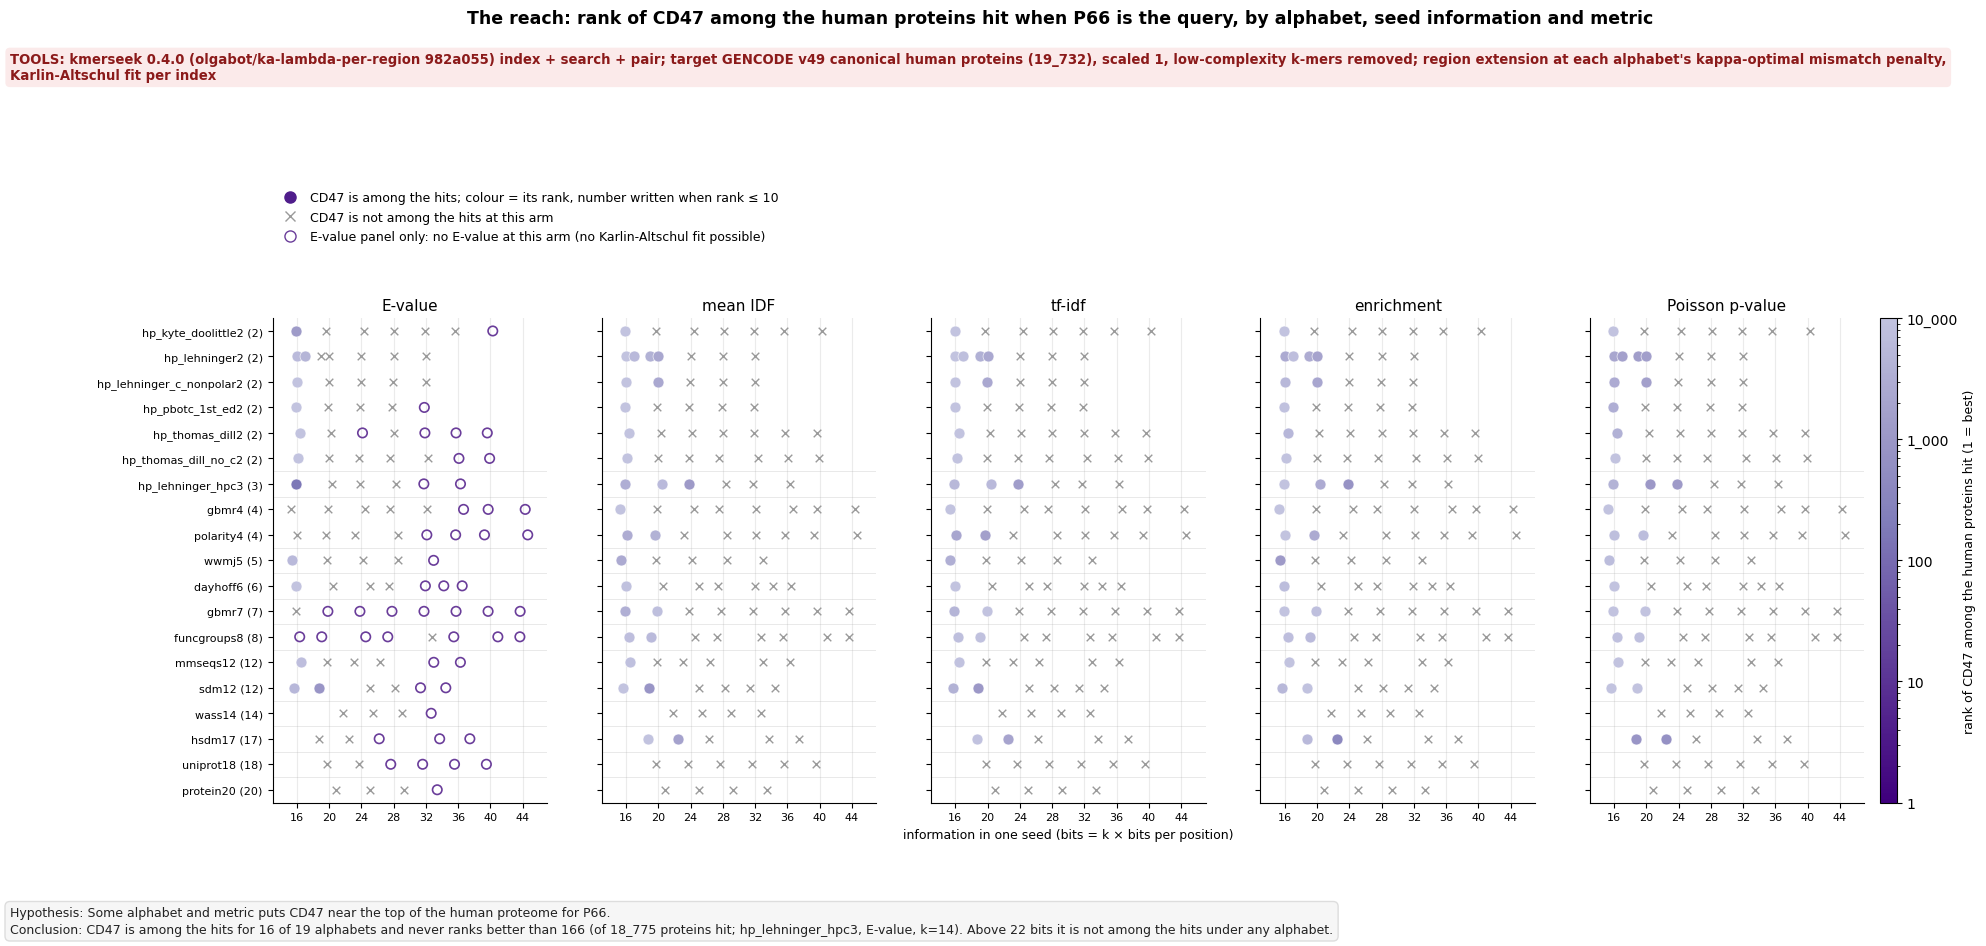

In [5]:
reach = au.rank_matrix(
    ranks, arms, "P66", "CD47", FIG / "241_reach_cd47_rank.png",
    "The reach: rank of CD47 among the human proteins hit when P66 is the query, by alphabet, seed information and metric",
    hypothesis="Some alphabet and metric puts CD47 near the top of the human proteome for P66.",
    conclusion=(lambda b: (
        f"CD47 is among the hits for {b.filter(pl.col('rank').is_not_null())['alphabet'].n_unique()} of 19 alphabets and never ranks better than "
        f"{b['rank'].min()} (of {b.filter(pl.col('rank') == b['rank'].min())['n_targets'][0]:_} proteins hit; "
        f"{b.filter(pl.col('rank') == b['rank'].min())['alphabet'][0]}, "
        f"{b.filter(pl.col('rank') == b['rank'].min())['metric'][0]}, k={b.filter(pl.col('rank') == b['rank'].min())['ksize'][0]}). "
        f"Above {b.filter(pl.col('rank').is_not_null())['bits'].max():.0f} bits it is not among the hits under any alphabet."))(au.best_per_alphabet(ranks, "P66")),
)
print(reach.filter(pl.col("partner_found")).select("alphabet", "ksize", "bits", "metric", "rank", "n_tied", "n_targets", "partner_value", "best_value", "top_gene").sort("alphabet", "ksize", "metric"))

## 5. The best any alphabet does, in one picture

For each alphabet, the best rank the partner reaches over every k and every one of the
five metrics, and which arm and metric got there. This is the one-line answer to "what
can this alphabet see".

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (38, 12)
┌──────────────────────────┬─────────┬───────┬────────┬───────────┬───────┬───────┬─────────────────┬───────────────┬─────────────────┬───────────────┬───────┐
│ alphabet                 ┆ classes ┆ rank  ┆ n_tied ┆ n_targets ┆ ksize ┆ bits  ┆ metric          ┆ partner_value ┆ found_from_bits ┆ found_to_bits ┆ query │
│ ---                      ┆ ---     ┆ ---   ┆ ---    ┆ ---       ┆ ---   ┆ ---   ┆ ---             ┆ ---           ┆ ---             ┆ ---           ┆ ---   │
│ str                      ┆ i64     ┆ i64   ┆ i64    ┆ i64       ┆ i64   ┆ f64   ┆ str             ┆ f64           ┆ f64             ┆ f64           ┆ str   │
╞══════════════════════════╪═════════╪═══════╪════════╪═══════════╪═══════╪═══════╪═════════════════╪═══════════════╪═════════════════╪═══════════════╪═══════╡
│ hp_kyte_doolittle2       ┆ 2       ┆ 7624  ┆ 1      ┆ 13945     ┆ 17    ┆ 15.93 ┆ Poisson p-value ┆ 0.015162      ┆ 15.93           ┆ 15.93         ┆ Ced9  │
│ hp_lehninger2         

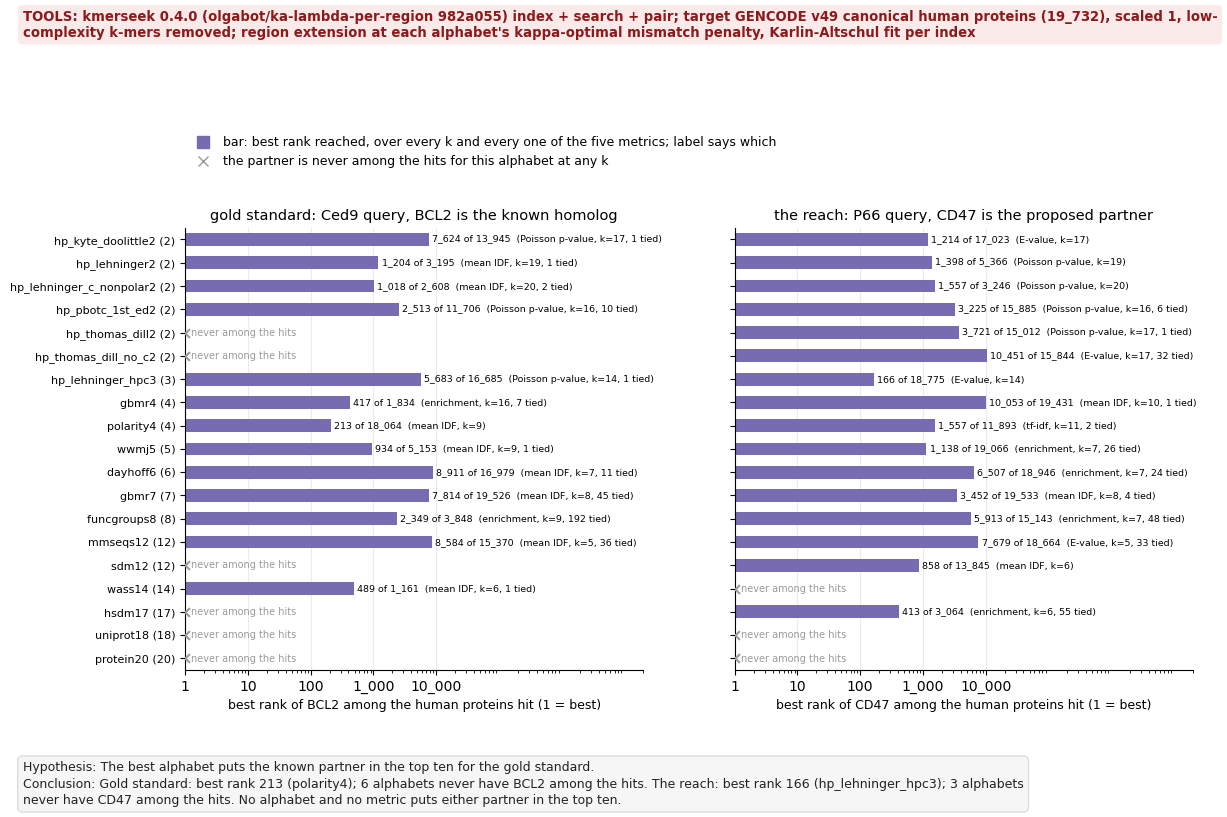

In [6]:
best = au.best_rank_figure(
    ranks, FIG / "241_best_rank_per_alphabet.png",
    hypothesis="The best alphabet puts the known partner in the top ten for the gold standard.",
    conclusion=(lambda g, r: (
        f"Gold standard: best rank {g['rank'].min()} ({g.filter(pl.col('rank') == g['rank'].min())['alphabet'][0]}); "
        f"{g.filter(pl.col('rank').is_null()).height} alphabets never have BCL2 among the hits. "
        f"The reach: best rank {r['rank'].min()} ({r.filter(pl.col('rank') == r['rank'].min())['alphabet'][0]}); "
        f"{r.filter(pl.col('rank').is_null()).height} alphabets never have CD47 among the hits. "
        f"No alphabet and no metric puts either partner in the top ten."))(au.best_per_alphabet(ranks, "Ced9"), au.best_per_alphabet(ranks, "P66")),
)
print(best.sort("query", "classes", "alphabet"))

## 6. Why: the partner's own E-value against chance

The rank is a symptom. The cause is the amount of evidence in the matched region. Here
is the E-value BCL2 and CD47 themselves get at every arm where they have one. E = 1 means
one region this good is expected by chance somewhere in the search; the ranks above are
what E-values in the thousands look like on a background of 19_732 proteins. The BCL2
region is the BH3 groove, 19 residues of exact HP match that extension grows to 26
residues with 2 mismatches: a 16 to 18 bit score against a database that needs about
32 bits for E = 1.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (19, 7)
┌───────┬──────────────────────────┬───────┬───────┬───────────────┬───────┬───────────┐
│ query ┆ alphabet                 ┆ ksize ┆ bits  ┆ partner_value ┆ rank  ┆ n_targets │
│ ---   ┆ ---                      ┆ ---   ┆ ---   ┆ ---           ┆ ---   ┆ ---       │
│ str   ┆ str                      ┆ i64   ┆ f64   ┆ f64           ┆ i64   ┆ i64       │
╞═══════╪══════════════════════════╪═══════╪═══════╪═══════════════╪═══════╪═══════════╡
│ Ced9  ┆ wwmj5                    ┆ 9     ┆ 19.77 ┆ 1954.636333   ┆ 1352  ┆ 5153      │
│ Ced9  ┆ hp_pbotc_1st_ed2         ┆ 16    ┆ 15.91 ┆ 10209.467342  ┆ 5558  ┆ 11706     │
│ Ced9  ┆ hp_lehninger2            ┆ 19    ┆ 19.0  ┆ 11172.693332  ┆ 2040  ┆ 3195      │
│ Ced9  ┆ hp_lehninger2            ┆ 17    ┆ 17.0  ┆ 29481.880667  ┆ 6101  ┆ 8883      │
│ Ced9  ┆ hp_lehninger2            ┆ 16    ┆ 16.0  ┆ 45097.582252  ┆ 9301  ┆ 12691     │
│ Ced9  ┆ wwmj5                    ┆ 7     ┆ 15.38 ┆ 73372.702995  ┆ 11359 ┆ 18363     │
│ P66 

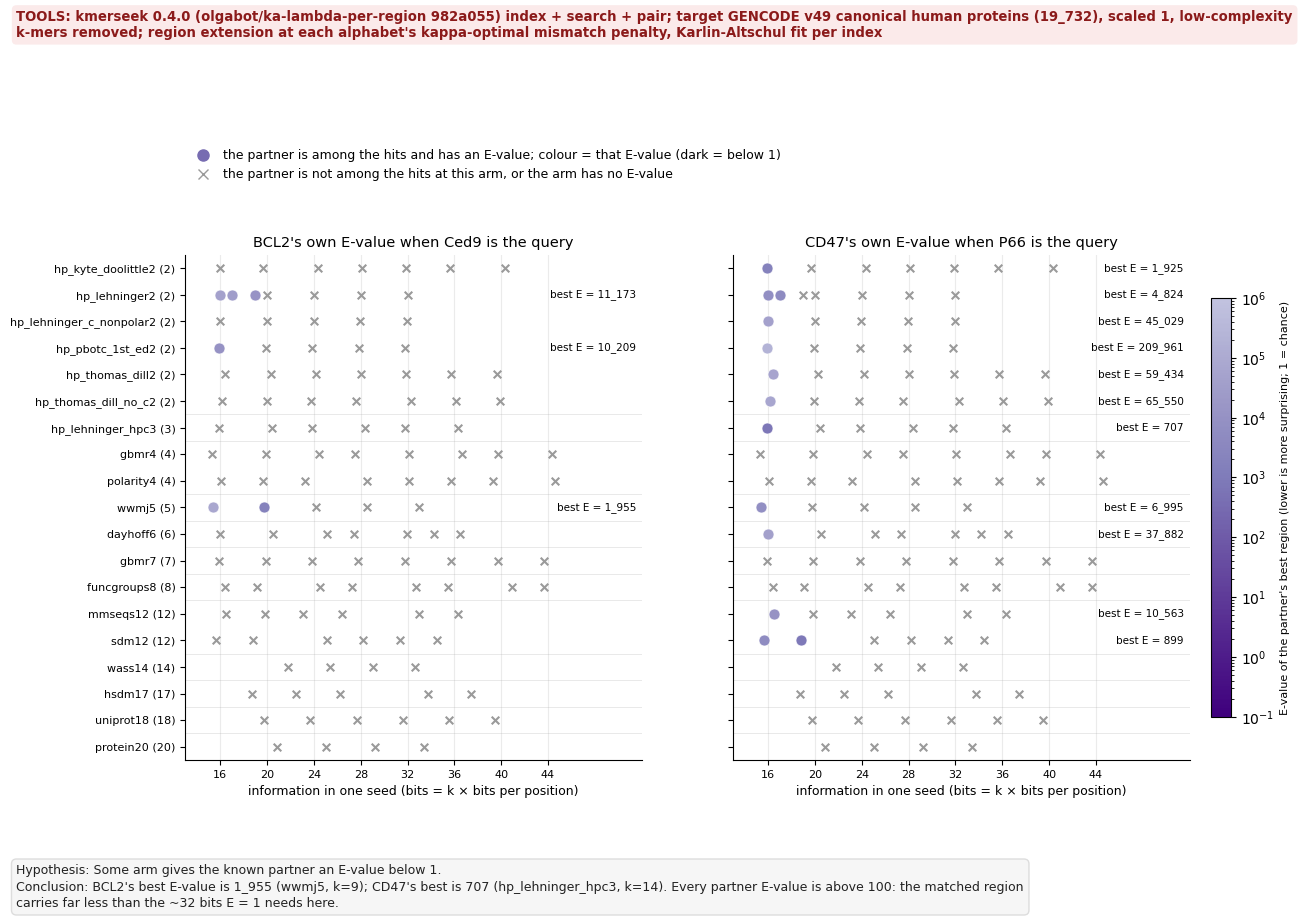

In [7]:
pe = au.partner_evalue_figure(
    ranks, arms, FIG / "241_partner_evalue_vs_chance.png",
    hypothesis="Some arm gives the known partner an E-value below 1.",
    conclusion=(lambda t: (
        f"BCL2's best E-value is {t.filter(pl.col('query') == 'Ced9')['partner_value'].min():_.0f} "
        f"({t.filter(pl.col('query') == 'Ced9').sort('partner_value')['alphabet'][0]}, "
        f"k={t.filter(pl.col('query') == 'Ced9').sort('partner_value')['ksize'][0]}); "
        f"CD47's best is {t.filter(pl.col('query') == 'P66')['partner_value'].min():_.0f} "
        f"({t.filter(pl.col('query') == 'P66').sort('partner_value')['alphabet'][0]}, "
        f"k={t.filter(pl.col('query') == 'P66').sort('partner_value')['ksize'][0]}). "
        f"Every partner E-value is above 100: the matched region carries far less than the ~32 bits E = 1 needs here."))(
        ranks.filter((pl.col("metric") == "E-value") & pl.col("partner_found"))
             .join(arms.select("alphabet", "ksize", "fitted"), on=["alphabet", "ksize"]).filter(pl.col("fitted") == True)),
)
print(pe.sort("query", "partner_value"))

## 7. The application: what BHF gets

BHF has no known partner, so the two panels show what any alphabet returns: the best
E-value of any human protein (left; a black ring where it is below 1, with the gene
named) and how many human proteins have at least one region (right).

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (40, 7)
┌──────────────────────────┬───────┬───────┬────────┬───────────────┬────────────┬──────────┐
│ alphabet                 ┆ ksize ┆ bits  ┆ fitted ┆ n_targets_BHF ┆ best_value ┆ top_gene │
│ ---                      ┆ ---   ┆ ---   ┆ ---    ┆ ---           ┆ ---        ┆ ---      │
│ str                      ┆ i64   ┆ f64   ┆ bool   ┆ i64           ┆ f64        ┆ str      │
╞══════════════════════════╪═══════╪═══════╪════════╪═══════════════╪════════════╪══════════╡
│ polarity4                ┆ 13    ┆ 23.2  ┆ true   ┆ 772           ┆ 0.609548   ┆ SCN10A   │
│ hp_lehninger_c_nonpolar2 ┆ 28    ┆ 27.97 ┆ true   ┆ 16            ┆ 0.844149   ┆ SFI1     │
│ gbmr7                    ┆ 8     ┆ 15.88 ┆ true   ┆ 19427         ┆ 0.990939   ┆ FXYD5    │
│ hp_lehninger_c_nonpolar2 ┆ 16    ┆ 15.98 ┆ true   ┆ 10143         ┆ 1.34456    ┆ MIEF1    │
│ hp_lehninger2            ┆ 28    ┆ 28.0  ┆ true   ┆ 11            ┆ 1.85407    ┆ SFI1     │
│ hp_thomas_dill2          ┆ 17    ┆ 16.42 ┆ 

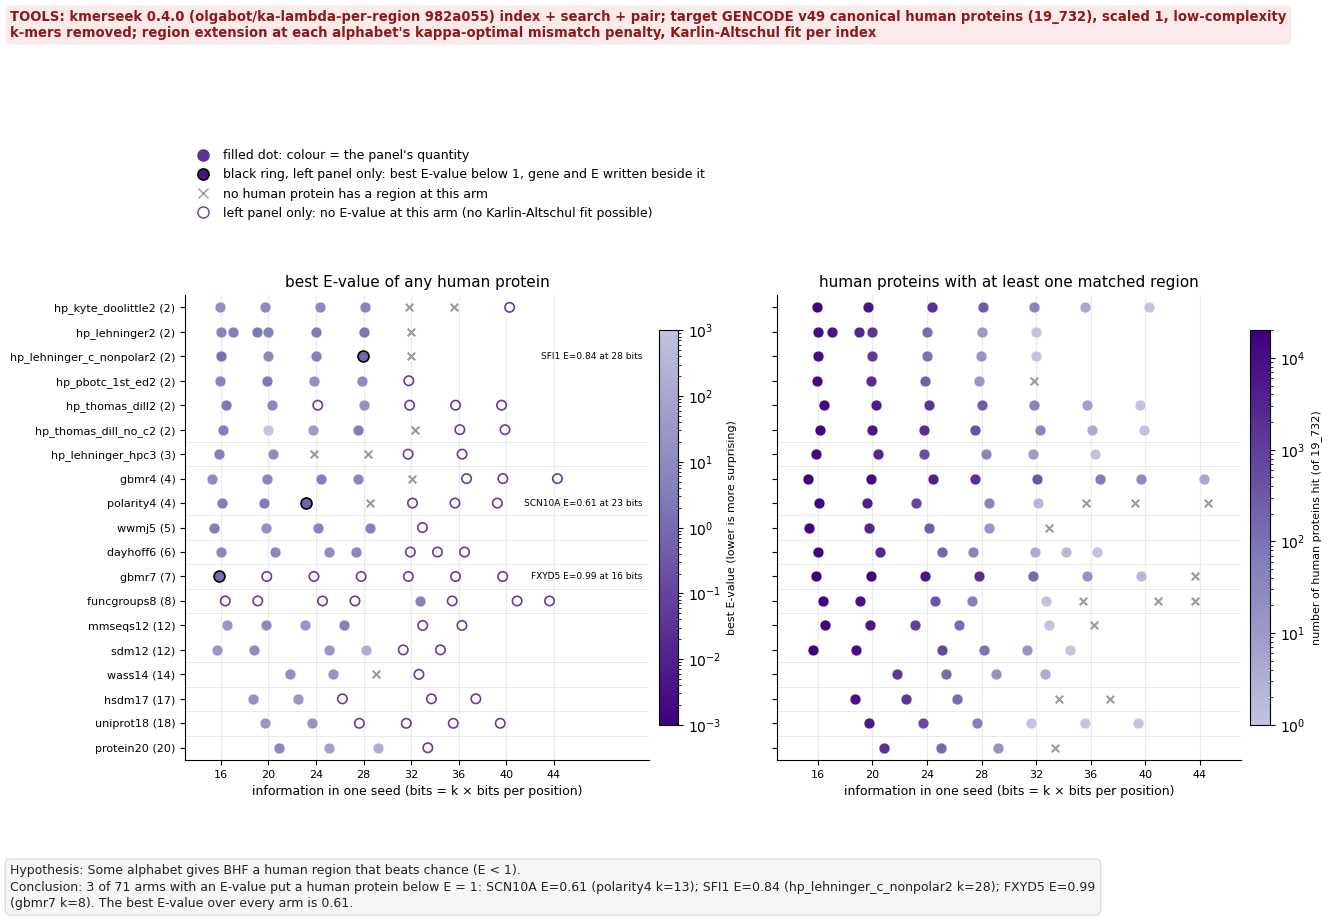

In [8]:
bhf = au.bhf_matrix(
    ranks, arms, FIG / "241_application_bhf.png",
    hypothesis="Some alphabet gives BHF a human region that beats chance (E < 1).",
    conclusion=(lambda e: (
        f"{e.filter(pl.col('best_value') < 1).height} of {e.filter(pl.col('fitted') == True).height} arms with an E-value put a human protein below E = 1: "
        + ("; ".join(f"{r['top_gene']} E={r['best_value']:.2g} ({r['alphabet']} k={r['ksize']})" for r in e.filter(pl.col('best_value') < 1).sort('best_value').iter_rows(named=True)) or "none")
        + f". The best E-value over every arm is {e['best_value'].min():.2g}."))(
        ranks.filter((pl.col("query") == "BHF") & (pl.col("metric") == "E-value"))
             .join(arms.select("alphabet", "ksize", "fitted"), on=["alphabet", "ksize"])),
)
print(bhf.filter(pl.col("n_targets_BHF") > 0).sort("best_value", nulls_last=True).head(40))

## 8. Cross-check against PR #44's P66 ladder and random-protein control

[PR #44](https://github.com/seanome/2024-kmerseek-analysis/pull/44) (`analysis/ranking-metrics-p66/`)
ran P66 against CD47 pairwise down a k ladder for four alphabets and, as a control,
against 300 random human proteins of similar length (242-404 aa). Its reading: CD47
appears only at short k (hp_lehninger2 last at k=20 with 2 shared k-mers, polarity4 at
k=12, funcgroups8 at k=8, protein20 never), and at k=18 26 of the 300 random proteins
match or beat CD47's 4 shared k-mers (91st percentile), at k=20 24 of 300 beat its 2 (92nd).

This sweep's pairwise layer is the same measurement, and its rank of CD47 among every
human protein hit is the same control with all 19_732 proteins as the sample instead
of 300. The table joins the two ladders on the k values both ran; every shared count
should agree exactly, since both call `kmerseek pair` on the same two sequences.

In [9]:
import json, subprocess

# PR #44's ladder, read from its branch so nothing is copied by hand.
def pr44_csv(name):
    ref = "origin/olgabot/ranking-metrics-and-p66"
    subprocess.run(["git", "fetch", "-q", "origin", "olgabot/ranking-metrics-and-p66"], check=False)
    out = subprocess.run(["git", "show", f"{ref}:analysis/ranking-metrics-p66/{name}"],
                         capture_output=True, text=True)
    if out.returncode != 0:
        print(f"PR #44's {name} not reachable: {out.stderr.strip()[:120]}")
        return None
    import io
    return pl.read_csv(io.StringIO(out.stdout))

theirs = pr44_csv("cd47_ladder.csv")
mine = []
for f in sorted((au.DATA / "pair").glob("*.P66.json")):
    a, k = f.name.replace(".P66.json", "").rsplit(".k", 1)
    d = json.loads(f.read_text())
    mine.append({"alphabet": a, "k": int(k), "shared_kmers_241": len(d["shared_kmers"]), "regions_241": len(d["regions"])})
mine = pl.DataFrame(mine)
if theirs is not None:
    joined = (theirs.rename({"shared_kmers": "shared_kmers_pr44", "regions": "regions_pr44"})
              .join(mine, on=["alphabet", "k"], how="inner")
              .with_columns((pl.col("shared_kmers_pr44") == pl.col("shared_kmers_241")).alias("agree"))
              .sort("alphabet", "k"))
    print(joined)
    print(f"\n{joined['agree'].sum()} of {joined.height} shared-k-mer counts agree on the k values both ladders ran")
last_k = (mine.filter(pl.col("shared_kmers_241") > 0).group_by("alphabet")
          .agg(pl.col("k").max().alias("last_k_with_shared_kmer_241")).sort("alphabet"))
print("\nlast k with any shared P66/CD47 k-mer, this sweep, all alphabets:")
print(last_k)

# CD47's rank among every human protein hit: the whole-proteome control.
cd47 = (ranks.filter((pl.col("query") == "P66") & (pl.col("alphabet") == "hp_lehninger2") & pl.col("partner_found")
                     & pl.col("metric").is_in(au.METRICS5 + ["shared k-mers"]))
        .select("ksize", "bits", "metric", "rank", "n_targets")
        .with_columns((100 * (1 - (pl.col("rank") - 1) / pl.col("n_targets"))).round(0).alias("percentile_among_hits"))
        .sort("ksize", "metric"))
print("\nCD47's rank among the human proteins hit by P66, hp_lehninger2 (PR #44's control: 91st-92nd percentile of 300 random proteins at k=18-20):")
print(cd47)

shape: (12, 7)
┌───────────────┬─────┬───────────────────┬──────────────┬──────────────────┬─────────────┬───────┐
│ alphabet      ┆ k   ┆ shared_kmers_pr44 ┆ regions_pr44 ┆ shared_kmers_241 ┆ regions_241 ┆ agree │
│ ---           ┆ --- ┆ ---               ┆ ---          ┆ ---              ┆ ---         ┆ ---   │
│ str           ┆ i64 ┆ i64               ┆ i64          ┆ i64              ┆ i64         ┆ bool  │
╞═══════════════╪═════╪═══════════════════╪══════════════╪══════════════════╪═════════════╪═══════╡
│ funcgroups8   ┆ 6   ┆ 58                ┆ 42           ┆ 58               ┆ 42          ┆ true  │
│ funcgroups8   ┆ 10  ┆ 0                 ┆ 0            ┆ 0                ┆ 0           ┆ true  │
│ funcgroups8   ┆ 12  ┆ 0                 ┆ 0            ┆ 0                ┆ 0           ┆ true  │
│ funcgroups8   ┆ 15  ┆ 0                 ┆ 0            ┆ 0                ┆ 0           ┆ true  │
│ hp_lehninger2 ┆ 20  ┆ 2                 ┆ 1            ┆ 2                ┆ 1      

## 9. Why so few regions have an E-value

This kmerseek build solves lambda from each region's own two spans. A region whose own
identity is above C / (1 + C), the point where a match stops being evidence at mismatch
penalty C, gets lambda 0 and E = inf. With the kappa-optimal penalties that limit is 62%
for hp_lehninger2 (C = 1.51) but only 12 to 19% for the 12- to 20-class alphabets
(C = 0.14 to 0.24), so nearly every extended region of those alphabets loses its E-value,
including the best ones.

Three alphabets lose every region for a second reason. The kappa-optimal penalty was
derived assuming equal class shares (1 / classes). On this proteome the chance match
probability is 0.39 for gbmr7 (one class holds most residues), 0.48 for hp_lehninger_hpc3
and 0.40 for gbmr4, and at those rates a chance position scores at or above zero, so no
lambda exists at any k. The right panel shows that drift for every alphabet; the fix is
to derive the penalty from the measured class shares (Sigma p_i^2, the chance match
probability) instead of 1 / classes.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ranking-three-cases/notebooks/hp_conservation_utils.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (19, 4)
┌──────────────────────────┬──────────────┬─────────┬─────────┐
│ alphabet                 ┆ chance_drift ┆ p_match ┆ penalty │
│ ---                      ┆ ---          ┆ ---     ┆ ---     │
│ str                      ┆ f64          ┆ f64     ┆ f64     │
╞══════════════════════════╪══════════════╪═════════╪═════════╡
│ gbmr7                    ┆ 0.19876      ┆ 0.393   ┆ 0.32    │
│ hp_lehninger_hpc3        ┆ 0.02573      ┆ 0.479   ┆ 0.87    │
│ gbmr4                    ┆ -0.00033     ┆ 0.401   ┆ 0.67    │
│ polarity4                ┆ -0.02564     ┆ 0.334   ┆ 0.54    │
│ sdm12                    ┆ -0.06516     ┆ 0.141   ┆ 0.24    │
│ wass14                   ┆ -0.06587     ┆ 0.089   ┆ 0.17    │
│ uniprot18                ┆ -0.0672      ┆ 0.072   ┆ 0.15    │
│ hsdm17                   ┆ -0.07144     ┆ 0.092   ┆ 0.18    │
│ protein20                ┆ -0.07274     ┆ 0.059   ┆ 0.14    │
│ dayhoff6                 ┆ -0.08006     ┆ 0.234   ┆ 0.41    │
│ mmseqs12               

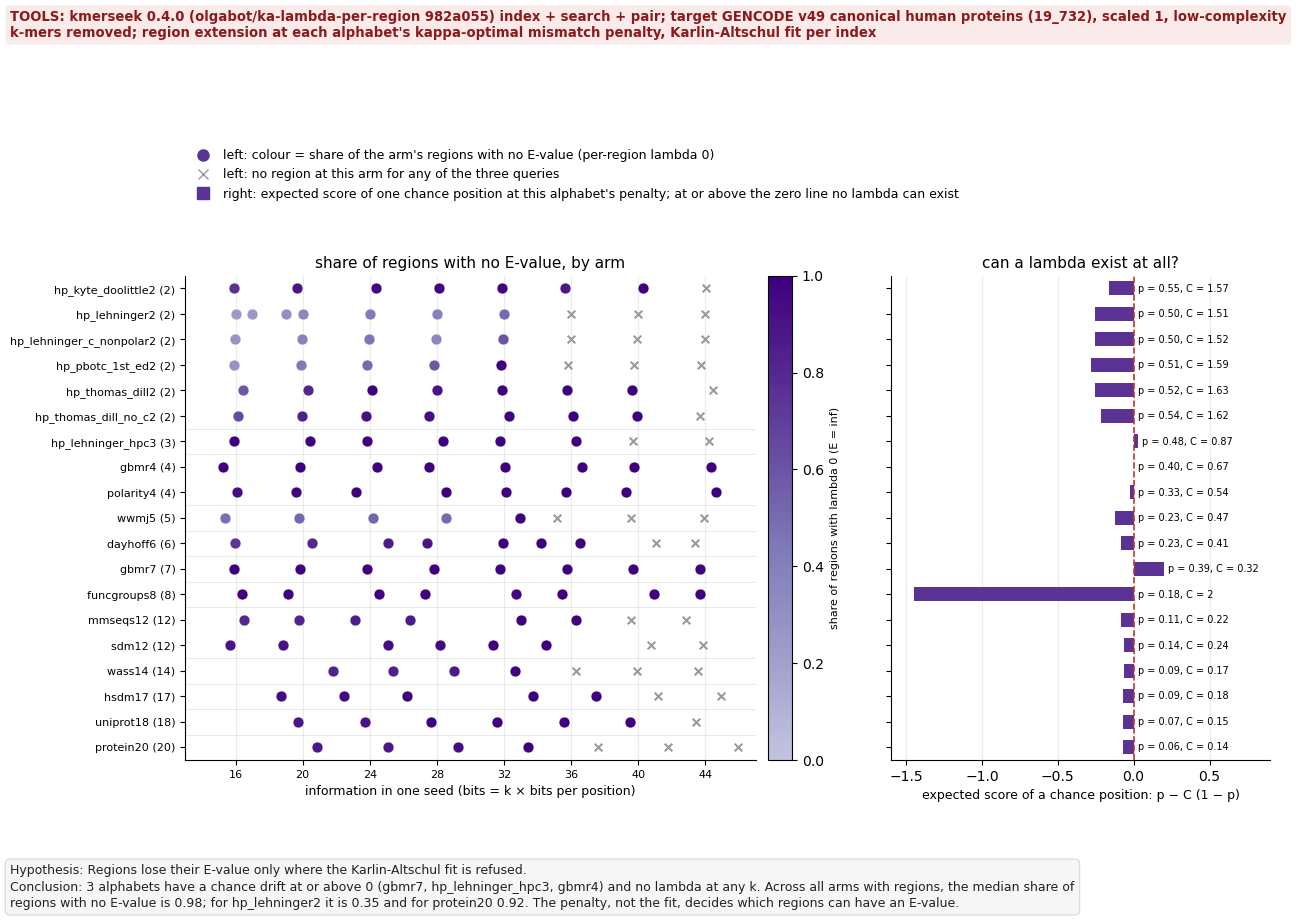

In [10]:
lz = au.lambda_zero_figure(
    arms, FIG / "241_no_evalue_mechanism.png",
    hypothesis="Regions lose their E-value only where the Karlin-Altschul fit is refused.",
    conclusion=(lambda a: (
        f"{a.filter(pl.col('chance_drift') >= -0.001)['alphabet'].n_unique()} alphabets have a chance drift at or above 0 "
        f"({', '.join(a.filter(pl.col('chance_drift') >= -0.001).sort('chance_drift', descending=True)['alphabet'])}) and no lambda at any k. "
        f"Across all arms with regions, the median share of regions with no E-value is {arms['frac_lambda_zero'].median():.2f}; "
        f"for hp_lehninger2 it is {arms.filter(pl.col('alphabet') == 'hp_lehninger2')['frac_lambda_zero'].mean():.2f} and for protein20 "
        f"{arms.filter(pl.col('alphabet') == 'protein20')['frac_lambda_zero'].mean():.2f}. The penalty, not the fit, decides which regions can have an E-value."))(
        arms.group_by("alphabet").agg(pl.col("chance_drift").first())),
)
print(lz)
print(arms.group_by("alphabet").agg(pl.col("frac_lambda_zero").mean().round(2).alias("mean_share_no_evalue"),
                                    (pl.col("frac_lambda_zero") >= 0.999).sum().alias("arms_with_no_evalue_at_all"),
                                    pl.len().alias("arms")).sort("mean_share_no_evalue", descending=True))

## 10. Conclusions

**No alphabet and no metric puts either known partner near the top of the human
proteome.** BCL2 is among the hits for 13 of 19 alphabets when Ced9 is the query, and its
best rank over every k and every metric is 213 of 18_064 proteins hit (polarity4, mean
IDF, k=9, 16 bits); under hp_lehninger2 it is 1_204 of 3_195 (mean IDF, k=19). CD47 is
among the hits for 16 of 19 alphabets when P66 is the query, best 166 of 18_775
(hp_lehninger_hpc3, E-value, k=14, 16 bits). Both partners are only in view below about
25 bits per seed, where thousands of human proteins are in view with them, and both
disappear before the seed carries the ~32 bits an E-value of 1 needs on this database.
Their own best E-values are 1_955 (BCL2, wwmj5 k=9) and 707 (CD47).

**The 20-letter alphabet is not the answer either.** protein20 and uniprot18 never have
BCL2 or CD47 among the hits at any k; wass14 never has CD47; hsdm17, sdm12 and the two
Thomas-Dill 2-letter alphabets never have BCL2. The coarse alphabets keep the pair in
view a few bits longer, at the price of a larger crowd.

**The pairwise layer agrees with PR #44** on every one of the 12 k values both ladders
ran, and this sweep's rank among 19_732 proteins is the whole-proteome form of PR #44's
300-random-protein control: under hp_lehninger2 and the five metrics, CD47 sits between
the 27th and the 86th percentile of the proteins P66 hits, never in the top 5%.

**BHF gets nothing that beats chance.** Of the 71 arms with an E-value, 3 put a human
protein just under E = 1 (SCN10A 0.61 at polarity4 k=13, SFI1 0.84 at hp_lehninger_c_nonpolar2
k=28, FXYD5 0.99 at gbmr7 k=8), which is what 71 independent searches are expected to
produce by chance.

**Two things about the E-value itself, which matter beyond these three proteins.**
(1) The per-region lambda gives E = inf to every region whose own identity is above
C / (1 + C); with the kappa penalties that removes 35% of hp_lehninger2 regions and
88 to 98% for the 12- to 20-class alphabets, and it removes the best-matching regions
first. (2) The kappa-optimal penalty assumes equal class shares; on this proteome
gbmr7, hp_lehninger_hpc3 and gbmr4 have a chance match rate high enough that a chance
position scores at or above zero, so no lambda exists for them at any k. 81 of 152 arms
ended without a Karlin-Altschul fit; above about 30 bits both curves run out of score
bins, and below it the many-class alphabets have curves too narrow to hold four bins
however many queries are searched.

**What this changes.** The E-value, mean IDF, tf-idf, enrichment and Poisson p-value
all rank the known partner in the hundreds to thousands, because the matched region
carries 16 to 25 bits against a background that needs 32. Ranking metrics cannot fix a
seed that is too short; what the gold standard needs is a longer region, which means
extension or chaining that survives past the identity limit, and a penalty derived
from the real class shares so that an E-value exists for it.